# Ad Campaign Conversion Experiment & Exposure Optimization

## Business Problem

A marketing team wants to understand whether showing users an advertisement
increases conversion compared with a public-service announcement (PSA).

The analysis has two objectives:

1. Evaluate the causal effect of Ad vs PSA exposure on conversion.
2. Identify whether conversion behavior differs across ad-exposure days and
   time periods to generate hypotheses for future experimentation.

### Primary Metric
Conversion Rate

### Primary Experiment
Ad vs PSA

### Key Statistical Question
Is the conversion rate in the Ad group significantly higher than in the PSA group?

In [33]:
import pandas as pd # Import the pandas library for data manipulation
import numpy as np # Import the numpy library for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for enhanced data visualizations

# Import statistical functions for hypothesis testing and power analysis
from scipy.stats import chi2_contingency # For chi-square test of independence
from statsmodels.stats.proportion import proportions_ztest # For z-test of proportions
from statsmodels.stats.contingency_tables import Table2x2 # For 2x2 contingency table analysis (e.g., odds ratio)
from statsmodels.stats.power import NormalIndPower # For sample size and power calculations

pd.set_option("display.max_columns", None) # Set pandas option to display all columns in a DataFrame

ALPHA = 0.05 # Significance level for hypothesis testing
POWER = 0.80 # Desired statistical power for experiment planning

sns.set_theme(style="whitegrid") # Set the seaborn theme for plots

## 1. Data Loading & Quality Checks

Before analyzing the experiment, validate:

- dataset dimensions
- column structure
- missing values
- duplicate users
- treatment/control groups
- conversion variable

In [34]:
df = pd.read_csv("marketing_AB.csv") # Load the dataset from a CSV file into a pandas DataFrame

print(f"Rows: {len(df):,}") # Print the total number of rows (users) in the DataFrame
print(f"Columns: {df.shape[1]}") # Print the total number of columns in the DataFrame
print("\nColumns:") # Print a header for the column names
print(df.columns.tolist()) # Print a list of all column names

display(df.head()) # Display the first 5 rows of the DataFrame to get a quick overview of the data

Rows: 588,101
Columns: 7

Columns:
['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [35]:
print("Missing values:") # Print a header for missing values
display(df.isna().sum()) # Display the count of missing values for each column

print("\nDuplicate user IDs:") # Print a header for duplicate user IDs
print(df["user id"].duplicated().sum()) # Print the total count of duplicate 'user id' values

print("\nTest groups:") # Print a header for test group distribution
display(df["test group"].value_counts()) # Display the count of users in each 'test group'

print("\nConversion:") # Print a header for conversion distribution
display(df["converted"].value_counts()) # Display the count of users for each 'converted' status

Missing values:


,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0



Duplicate user IDs:
0

Test groups:


,count
test group,
ad,564577
psa,23524



Conversion:


,count
converted,
False,573258
True,14843


In [36]:
assert df["user id"].is_unique, "Duplicate user IDs detected." # Assert that all 'user id' values are unique, raising an error if duplicates exist
assert df["test group"].isin(["ad", "psa"]).all(), "Unexpected test group found." # Assert that 'test group' contains only 'ad' or 'psa' values
assert df["converted"].isin([True, False]).all(), "Unexpected conversion values found." # Assert that 'converted' contains only True or False values

print("Data quality checks passed.") # Print a success message if all assertions pass

Data quality checks passed.


## 2. Experiment Structure

The dataset contains two experimental groups:

- **Ad:** Users exposed to the advertisement
- **PSA:** Users exposed to the public-service announcement

The primary outcome is whether the user converted.

### Hypotheses

**H₀:** Conversion rate is equal between the Ad and PSA groups.

**H₁:** Conversion rate is higher in the Ad group than in the PSA group.

We use:

- α = 0.05
- statistical power = 80%

In [37]:
group_summary = ( # Create a summary table of user counts and conversions by test group
    df.groupby("test group") # Group the DataFrame by 'test group' (ad vs psa)
      .agg( # Aggregate the data
          users=("user id", "count"), # Count the number of unique 'user id's as 'users'
          conversions=("converted", "sum") # Sum the 'converted' (True/False) values to get total conversions
      )
)

group_summary["conversion_rate"] = ( # Calculate the conversion rate for each group
    group_summary["conversions"] / group_summary["users"] # Conversions divided by total users
)

group_summary["conversion_rate_pct"] = ( # Calculate conversion rate as a percentage
    group_summary["conversion_rate"] * 100
)

display(group_summary) # Display the summary table

,users,conversions,conversion_rate,conversion_rate_pct
test group,,,,
ad,564577,14423,0.025547,2.554656
psa,23524,420,0.017854,1.785411


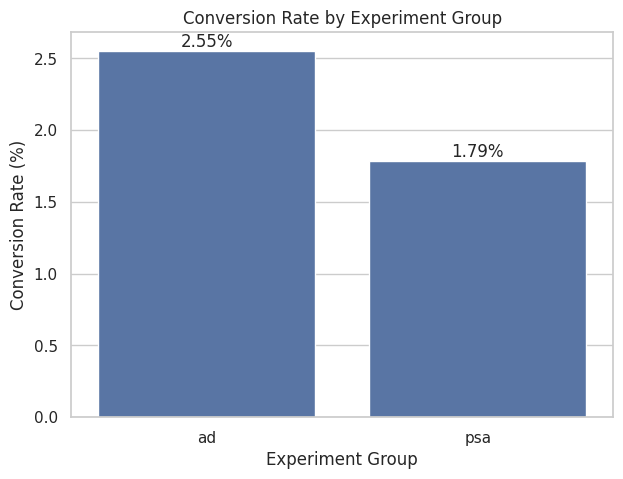

In [38]:
plot_df = group_summary.reset_index() # Convert the group_summary DataFrame index into a column for plotting

plt.figure(figsize=(7, 5)) # Create a new figure with a specified size

ax = sns.barplot( # Create a bar plot using seaborn
    data=plot_df, # Use the plot_df DataFrame as data source
    x="test group", # Map 'test group' to the x-axis
    y="conversion_rate_pct" # Map 'conversion_rate_pct' to the y-axis
)

ax.set_title("Conversion Rate by Experiment Group") # Set the title of the plot
ax.set_xlabel("Experiment Group") # Set the label for the x-axis
ax.set_ylabel("Conversion Rate (%)") # Set the label for the y-axis

for container in ax.containers: # Iterate through the bar containers to add labels
    ax.bar_label(container, fmt="%.2f%%") # Add labels to the bars, formatted as percentages

plt.show() # Display the plot

## 3. Primary Experiment: Ad vs PSA

The primary metric is conversion rate.

We test whether:

\[
p_{Ad} > p_{PSA}
\]

where:

- \(p_{Ad}\) = conversion rate among users exposed to the Ad
- \(p_{PSA}\) = conversion rate among users exposed to the PSA

Because the experiment contains a large number of observations in each group,
a two-sample test for proportions is appropriate.


In [39]:
ad = df[df["test group"] == "ad"] # Filter DataFrame to get data for the 'ad' group
psa = df[df["test group"] == "psa"] # Filter DataFrame to get data for the 'psa' group

ad_conversions = ad["converted"].sum() # Calculate total conversions in the 'ad' group
ad_users = len(ad) # Calculate total users in the 'ad' group

psa_conversions = psa["converted"].sum() # Calculate total conversions in the 'psa' group
psa_users = len(psa) # Calculate total users in the 'psa' group

ad_rate = ad_conversions / ad_users # Calculate conversion rate for the 'ad' group
psa_rate = psa_conversions / psa_users # Calculate conversion rate for the 'psa' group

z_stat, p_value = proportions_ztest( # Perform a two-sample z-test for proportions
    count=[ad_conversions, psa_conversions], # Number of successes (conversions) for each group
    nobs=[ad_users, psa_users], # Number of observations (users) for each group
    alternative="larger" # Specify a one-sided test (alternative hypothesis: ad rate is larger than psa rate)
)

print(f"Ad conversion rate:  {ad_rate:.4%}") # Print the conversion rate for the 'ad' group
print(f"PSA conversion rate: {psa_rate:.4%}") # Print the conversion rate for the 'psa' group
print(f"\nAbsolute lift: {(ad_rate - psa_rate):.4%}") # Print the absolute difference in conversion rates
print(f"Relative lift: {(ad_rate / psa_rate - 1):.2%}") # Print the relative difference in conversion rates
print(f"\nZ-statistic: {z_stat:.3f}") # Print the calculated Z-statistic
print(f"P-value: {p_value:.6f}") # Print the p-value from the z-test

Ad conversion rate:  2.5547%
PSA conversion rate: 1.7854%

Absolute lift: 0.7692%
Relative lift: 43.09%

Z-statistic: 7.370
P-value: 0.000000


In [9]:
if p_value < ALPHA:
    print("Result: Reject H₀.")
    print("The Ad group has statistically higher conversion than the PSA group.")
else:
    print("Result: Fail to reject H₀.")
    print("There is insufficient evidence that the Ad group has higher conversion.")

Result: Reject H₀.
The Ad group has statistically higher conversion than the PSA group.


## 4. Business Effect Size

Statistical significance answers:

> Is the difference unlikely to be explained by sampling variation?

Effect size answers:

> How large is the difference?

We report:

- absolute conversion-rate lift
- relative conversion-rate lift
- odds ratio
- 95% confidence interval

In [40]:
absolute_lift = ad_rate - psa_rate # Calculate the absolute difference in conversion rates
relative_lift = absolute_lift / psa_rate # Calculate the relative difference in conversion rates

print(f"Absolute lift: {absolute_lift:.4%}") # Print the absolute lift formatted as a percentage
print(f"Relative lift: {relative_lift:.2%}") # Print the relative lift formatted as a percentage

Absolute lift: 0.7692%
Relative lift: 43.09%


In [41]:
# Build a 2x2 table:
# rows = experiment groups
# columns = conversion outcome

table = pd.crosstab( # Create a contingency table
    df["test group"], # Use 'test group' as index (rows)
    df["converted"] # Use 'converted' as columns
).reindex( # Reindex the table to ensure consistent order of rows and columns
    index=["ad", "psa"], # Specify the order of 'test group' rows
    columns=[True, False] # Specify the order of 'converted' columns (True for converted, False for not converted)
)

display(table) # Display the 2x2 contingency table

converted,True,False
test group,,
ad,14423,550154
psa,420,23104


In [42]:
table_array = table.values # Extract the numerical values from the contingency table as a NumPy array

odds_model = Table2x2(table_array) # Create a Table2x2 object from statsmodels for odds ratio calculation

odds_ratio = odds_model.oddsratio # Calculate the odds ratio
or_ci_low, or_ci_high = odds_model.oddsratio_confint() # Calculate the 95% confidence interval for the odds ratio

print(f"Odds Ratio (Ad vs PSA): {odds_ratio:.3f}") # Print the calculated odds ratio
print(f"95% CI: [{or_ci_low:.3f}, {or_ci_high:.3f}]") # Print the 95% confidence interval

Odds Ratio (Ad vs PSA): 1.442
95% CI: [1.308, 1.590]


In [43]:
if odds_ratio > 1: # Check if the odds ratio is greater than 1
    print( # If true, the Ad group has higher odds of conversion
        f"Users in the Ad group had approximately "
        f"{(odds_ratio - 1) * 100:.1f}% higher odds of conversion "
        f"than users in the PSA group."
    )
else: # If the odds ratio is not greater than 1 (i.e., less than or equal to 1)
    print( # If true, the Ad group has lower or equal odds of conversion
        f"Users in the Ad group had approximately "
        f"{(1 - odds_ratio) * 100:.1f}% lower odds of conversion "
        f"than users in the PSA group."
    )

Users in the Ad group had approximately 44.2% higher odds of conversion than users in the PSA group.


In [44]:
# Confidence Interval for Absolute Lift

from statsmodels.stats.proportion import confint_proportions_2indep # Import function for confidence interval of difference in proportions

ci_low, ci_high = confint_proportions_2indep( # Calculate the confidence interval for the difference between two independent proportions
    count1=ad_conversions, # Number of conversions in the first group (Ad)
    nobs1=ad_users, # Number of observations in the first group (Ad)
    count2=psa_conversions, # Number of conversions in the second group (PSA)
    nobs2=psa_users, # Number of observations in the second group (PSA)
    compare="diff", # Specify that we want the confidence interval for the difference (prop1 - prop2)
    method="wald" # Use the Wald method for calculating the confidence interval
)

print(f"Absolute conversion-rate lift: {absolute_lift:.4%}") # Print the point estimate for absolute lift
print(f"95% CI: [{ci_low:.4%}, {ci_high:.4%}]") # Print the 95% confidence interval for the absolute lift

Absolute conversion-rate lift: 0.7692%
95% CI: [0.5951%, 0.9434%]


In [45]:
print( # Print a summary statement about the estimated conversion rate difference and its confidence interval
    f"The estimated conversion-rate difference is "
    f"{absolute_lift:.4%}, with a 95% confidence interval "
    f"from {ci_low:.4%} to {ci_high:.4%}."
)

The estimated conversion-rate difference is 0.7692%, with a 95% confidence interval from 0.5951% to 0.9434%.


## Experiment Result Visualization

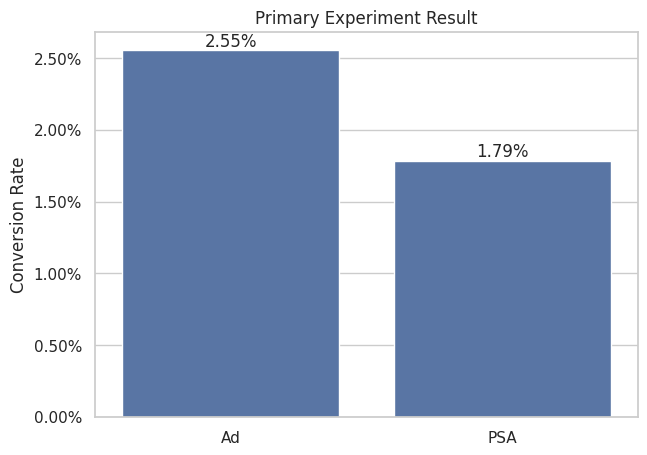

In [46]:
result_df = pd.DataFrame({ # Create a DataFrame to store the conversion rates for plotting
    "Group": ["Ad", "PSA"], # Define the group names
    "Conversion Rate": [ad_rate, psa_rate] # Define the conversion rates for each group
})

plt.figure(figsize=(7, 5)) # Create a new figure with a specified size

ax = sns.barplot( # Create a bar plot using seaborn
    data=result_df, # Use the result_df DataFrame as data source
    x="Group", # Map 'Group' to the x-axis
    y="Conversion Rate" # Map 'Conversion Rate' to the y-axis
)

ax.set_title("Primary Experiment Result") # Set the title of the plot
ax.set_ylabel("Conversion Rate") # Set the label for the y-axis
ax.set_xlabel("") # Remove the x-axis label as 'Group' is self-explanatory

ax.yaxis.set_major_formatter( # Format the y-axis ticks as percentages
    plt.FuncFormatter(lambda y, _: f"{y:.2%}")
)

for container in ax.containers: # Iterate through the bar containers to add labels
    labels = [f"{bar.get_height():.2%}" for bar in container] # Get the height of each bar and format as percentage
    ax.bar_label(container, labels=labels) # Add labels to the bars

plt.show() # Display the plot

## 5. Experiment Planning: Required Sample Size

To understand whether the observed effect would be detectable in a future
experiment, we estimate the sample size required for:

- α = 0.05
- power = 80%
- equal allocation between Ad and PSA groups
- baseline conversion rate based on the PSA group
- target conversion rate based on the observed Ad-group rate

This is a retrospective planning exercise, not a replacement for the original
experiment.

In [47]:
from statsmodels.stats.power import NormalIndPower # Import the NormalIndPower class for power analysis

baseline_rate = psa_rate # Set the baseline conversion rate using the observed PSA group rate
target_rate = ad_rate # Set the target conversion rate using the observed Ad group rate

pooled_rate = (baseline_rate + target_rate) / 2 # Calculate the pooled proportion, which is the average of the two rates

effect_size = ( # Calculate Cohen's h for a two-sample proportions test
    target_rate - baseline_rate # Difference between target and baseline rates
) / np.sqrt( # Divided by the standard deviation under the pooled proportion
    pooled_rate * (1 - pooled_rate)
)

analysis = NormalIndPower() # Create an instance of the NormalIndPower class

required_n = analysis.solve_power( # Calculate the required sample size per group
    effect_size=effect_size, # The calculated effect size
    power=POWER, # Desired statistical power (0.80)
    alpha=ALPHA, # Significance level (0.05)
    ratio=1, # Ratio of sample sizes (n2/n1 = 1 for equal allocation)
    alternative="larger" # Specify a one-sided test, matching the primary experiment hypothesis
)

print(f"Baseline conversion rate: {baseline_rate:.4%}") # Print the baseline conversion rate
print(f"Target conversion rate:   {target_rate:.4%}") # Print the target conversion rate
print(f"Required sample size per group: {np.ceil(required_n):,.0f}") # Print the required sample size for one group (rounded up to nearest whole number)
print(f"Required total sample size: {np.ceil(required_n * 2):,.0f}") # Print the total required sample size (for both groups)

Baseline conversion rate: 1.7854%
Target conversion rate:   2.5547%
Required sample size per group: 4,437
Required total sample size: 8,873


## 6. Secondary Analysis: Ad Exposure Day

The experiment establishes the overall difference between Ad and PSA.

We next examine whether conversion rates vary by the day on which users
received the highest number of ad exposures.

This is a segmentation analysis.

It identifies associations and hypotheses for future experiments;
it does not establish that changing the day of exposure will cause the
observed conversion difference.

In [48]:
day_summary = ( # Create a summary table of user counts and conversions by the most frequent ad day
    df.groupby("most ads day") # Group the DataFrame by 'most ads day'
      .agg( # Aggregate the data
          users=("user id", "count"), # Count the number of unique 'user id's as 'users'
          conversions=("converted", "sum") # Sum the 'converted' (True/False) values to get total conversions
      )
)

day_summary["conversion_rate"] = ( # Calculate the conversion rate for each day
    day_summary["conversions"] / day_summary["users"]
)

day_summary["conversion_rate_pct"] = ( # Calculate conversion rate as a percentage
    day_summary["conversion_rate"] * 100
)

day_summary = day_summary.sort_values( # Sort the summary DataFrame by conversion rate in descending order
    "conversion_rate",
    ascending=False
)

display(day_summary) # Display the summary table

,users,conversions,conversion_rate,conversion_rate_pct
most ads day,,,,
Monday,87073,2857,0.032812,3.281155
Tuesday,77479,2312,0.029840,2.984034
Wednesday,80908,2018,0.024942,2.494191
Sunday,85391,2090,0.024476,2.447565
Friday,92608,2057,0.022212,2.221190
Thursday,82982,1790,0.021571,2.157094
Saturday,81660,1719,0.021051,2.105070


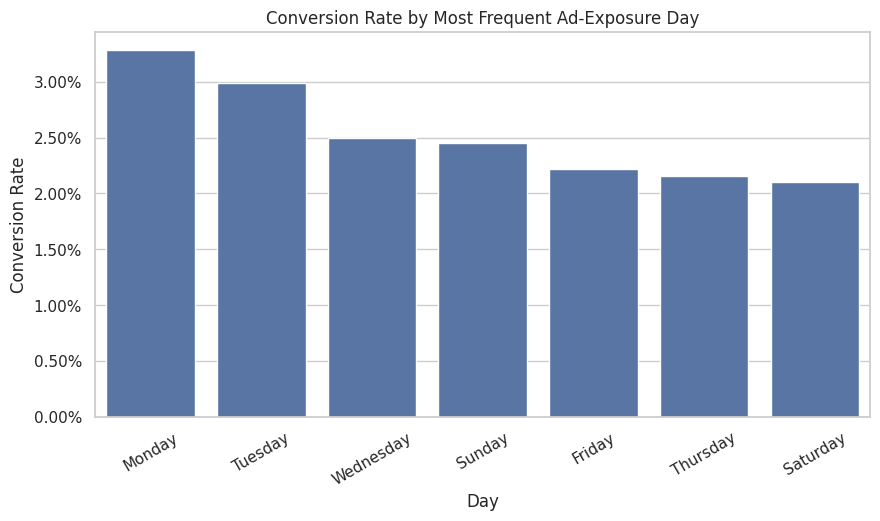

In [49]:
# Day-Level Visualization

plt.figure(figsize=(10, 5)) # Create a new figure with a specified size

ax = sns.barplot( # Create a bar plot using seaborn
    data=day_summary.reset_index(), # Use the day_summary DataFrame (with 'most ads day' as a column) as data source
    x="most ads day", # Map 'most ads day' to the x-axis
    y="conversion_rate" # Map 'conversion_rate' to the y-axis
)

ax.set_title("Conversion Rate by Most Frequent Ad-Exposure Day") # Set the title of the plot
ax.set_xlabel("Day") # Set the label for the x-axis
ax.set_ylabel("Conversion Rate") # Set the label for the y-axis

ax.yaxis.set_major_formatter( # Format the y-axis ticks as percentages
    plt.FuncFormatter(lambda y, _: f"{y:.2%}")
)

plt.xticks(rotation=30) # Rotate x-axis labels by 30 degrees for better readability
plt.show() # Display the plot

In [50]:
best_day = day_summary.index[0] # Get the day with the highest conversion rate (first row after sorting)
worst_day = day_summary.index[-1] # Get the day with the lowest conversion rate (last row after sorting)

best_rate = day_summary.iloc[0]["conversion_rate"] # Get the conversion rate for the best day
worst_rate = day_summary.iloc[-1]["conversion_rate"] # Get the conversion rate for the worst day

print(f"Highest observed conversion day: {best_day} ({best_rate:.2%})") # Print the best day and its conversion rate
print(f"Lowest observed conversion day:  {worst_day} ({worst_rate:.2%})") # Print the worst day and its conversion rate
print(f"Absolute difference: {(best_rate - worst_rate):.2%}") # Print the absolute difference between the best and worst rates

Highest observed conversion day: Monday (3.28%)
Lowest observed conversion day:  Saturday (2.11%)
Absolute difference: 1.18%


In [51]:
# Chi-Square Test for Day

day_table = pd.crosstab( # Create a contingency table
    df["most ads day"], # Use 'most ads day' as index (rows)
    df["converted"] # Use 'converted' as columns
)

display(day_table) # Display the contingency table

chi2, p_value, dof, expected = chi2_contingency(day_table) # Perform the chi-square test of independence

print(f"Chi-square statistic: {chi2:.2f}") # Print the chi-square statistic
print(f"Degrees of freedom: {dof}") # Print the degrees of freedom
print(f"P-value: {p_value:.6g}") # Print the p-value

converted,False,True
most ads day,,
Friday,90551,2057
Monday,84216,2857
Saturday,79941,1719
Sunday,83301,2090
Thursday,81192,1790
Tuesday,75167,2312
Wednesday,78890,2018


Chi-square statistic: 410.05
Degrees of freedom: 6
P-value: 1.93218e-85


In [52]:
# calculate Cramér's V. # Comment indicating the purpose of the following calculation

n = day_table.values.sum() # Total number of observations (sum of all cells in the contingency table)
min_dimension = min(day_table.shape) - 1 # Minimum dimension of the table minus 1, used in Cramer's V formula

cramers_v = np.sqrt( # Calculate Cramer's V
    chi2 / (n * min_dimension) # Formula for Cramer's V
)

print(f"Cramer's V: {cramers_v:.4f}") # Print the calculated Cramer's V, a measure of association between categorical variables

Cramer's V: 0.0264


### Interpretation

The chi-square test evaluates whether conversion status and most-frequent
ad-exposure day are statistically independent.

A statistically significant result indicates an association between the two
variables.

However, this analysis is observational. It does not establish that changing
the ad-exposure day would cause conversion to change.

The observed day-level differences should therefore be treated as hypotheses
for future randomized experiments rather than causal conclusions.


In [53]:
# Secondary Analysis: Time Slot
def categorize_hour(hour): # Define a function to categorize hours into time slots
    if 5 <= hour < 12: # Morning (5 AM to 11 AM)
        return "Morning"
    elif 12 <= hour < 17: # Afternoon (12 PM to 4 PM)
        return "Afternoon"
    elif 17 <= hour < 21: # Evening (5 PM to 8 PM)
        return "Evening"
    else: # Night (9 PM to 4 AM)
        return "Night"


df["time_slot"] = df["most ads hour"].apply(categorize_hour) # Apply the categorize_hour function to create a new 'time_slot' column

In [54]:
time_summary = ( # Create a summary table of user counts and conversions by time slot
    df.groupby("time_slot") # Group the DataFrame by 'time_slot'
      .agg( # Aggregate the data
          users=("user id", "count"), # Count the number of unique 'user id's as 'users'
          conversions=("converted", "sum") # Sum the 'converted' (True/False) values to get total conversions
      )
)

time_summary["conversion_rate"] = ( # Calculate the conversion rate for each time slot
    time_summary["conversions"] / # Conversions divided by total users
    time_summary["users"]
)

time_summary = time_summary.sort_values( # Sort the summary DataFrame by conversion rate in descending order
    "conversion_rate",
    ascending=False
)

display(time_summary) # Display the summary table

,users,conversions,conversion_rate
time_slot,,,
Evening,126586,3545,0.028005
Afternoon,222851,6065,0.027215
Night,95646,2256,0.023587
Morning,143018,2977,0.020816


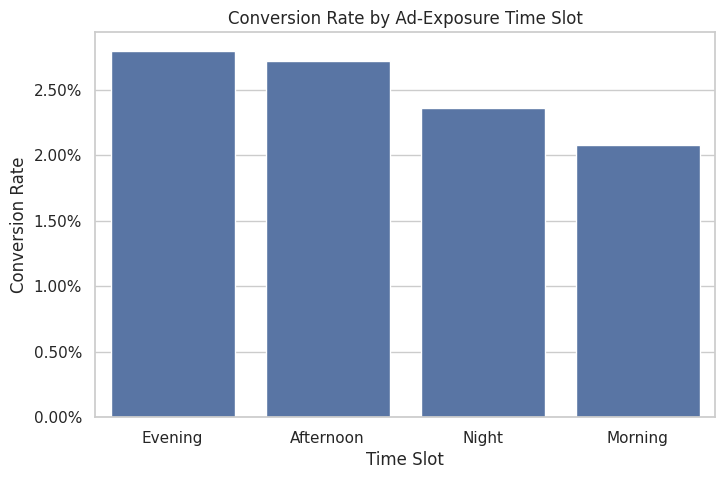

In [55]:
# Visualization

plt.figure(figsize=(8, 5)) # Create a new figure with a specified size

ax = sns.barplot( # Create a bar plot using seaborn
    data=time_summary.reset_index(), # Use the time_summary DataFrame (with 'time_slot' as a column) as data source
    x="time_slot", # Map 'time_slot' to the x-axis
    y="conversion_rate" # Map 'conversion_rate' to the y-axis
)

ax.set_title("Conversion Rate by Ad-Exposure Time Slot") # Set the title of the plot
ax.set_xlabel("Time Slot") # Set the label for the x-axis
ax.set_ylabel("Conversion Rate") # Set the label for the y-axis

ax.yaxis.set_major_formatter( # Format the y-axis ticks as percentages
    plt.FuncFormatter(lambda y, _: f"{y:.2%}")
)

plt.show() # Display the plot

In [56]:
# chi-square # Comment indicating the purpose of the following calculation

time_table = pd.crosstab( # Create a contingency table
    df["time_slot"], # Use 'time_slot' as index (rows)
    df["converted"] # Use 'converted' as columns
)

chi2_time, p_time, dof_time, expected_time = chi2_contingency( # Perform the chi-square test of independence
    time_table
)

print(f"Chi-square statistic: {chi2_time:.2f}") # Print the chi-square statistic
print(f"Degrees of freedom: {dof_time}") # Print the degrees of freedom
print(f"P-value: {p_time:.6g}") # Print the p-value

Chi-square statistic: 199.10
Degrees of freedom: 3
P-value: 6.59646e-43


## 7. Exploratory Behavioral Analysis: Ad Exposure

Users with different conversion outcomes exhibit different levels of observed
ad exposure.

This analysis is descriptive and should not be interpreted causally because
ad exposure may be correlated with user engagement and other behavioral factors.

In [57]:
exposure_summary = ( # Create a summary of 'total ads' by 'converted' status
    df.groupby("converted")["total ads"] # Group by 'converted' and select 'total ads' column
      .agg(["count", "mean", "median", "std"]) # Aggregate with count, mean, median, and standard deviation
) # This shows how ad exposure differs between converted and non-converted users

display(exposure_summary) # Display the summary table

,count,mean,median,std
converted,,,,
False,573258,23.291495,13.0,40.863176
True,14843,83.887759,64.0,87.455498


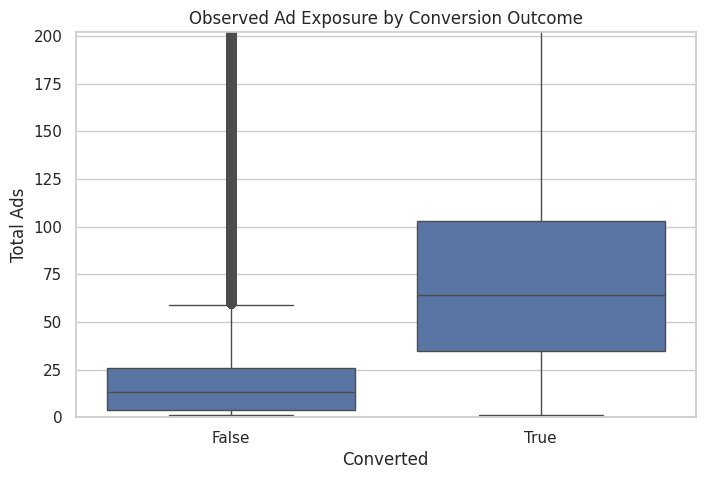

In [58]:
plt.figure(figsize=(8, 5)) # Create a new figure with a specified size

sns.boxplot( # Create a box plot using seaborn
    data=df, # Use the main DataFrame as data source
    x="converted", # Map 'converted' status to the x-axis
    y="total ads" # Map 'total ads' to the y-axis
)

plt.ylim(0, df["total ads"].quantile(0.99)) # Set the y-axis limits to focus on the majority of data, capping outliers at the 99th percentile
plt.title("Observed Ad Exposure by Conversion Outcome") # Set the title of the plot
plt.xlabel("Converted") # Set the label for the x-axis
plt.ylabel("Total Ads") # Set the label for the y-axis

plt.show() # Display the plot

# 8. Executive Summary

## Primary Experiment

The Ad group and PSA group were compared using conversion rate as the primary
metric.

The analysis reports:

- conversion rate for each group
- absolute conversion-rate lift
- relative conversion-rate lift
- statistical significance
- odds ratio and confidence interval

## Exposure Segmentation

Conversion rates were also analyzed by:

- most-frequent ad-exposure day
- ad-exposure time slot

These analyses identify statistically significant associations and potential
segments for future experimentation.

## Product / Marketing Implication

The primary experiment provides evidence about the overall effect of Ad versus
PSA exposure.

The day/time analysis should be used to formulate follow-up hypotheses rather
than treated as causal evidence.

### Recommended Next Experiment

Test ad timing or exposure strategy using randomized assignment, while
pre-specifying:

1. Primary metric: conversion rate
2. Minimum detectable effect
3. Experiment duration
4. Treatment/control allocation
5. Exposure-frequency constraints
6. Statistical significance threshold

In [59]:
# Key Metrices

summary = pd.DataFrame({ # Create a DataFrame to summarize key metrics
    "Metric": [ # List of metric names
        "Ad conversion rate",
        "PSA conversion rate",
        "Absolute lift",
        "Relative lift",
        "Z-statistic",
        "P-value",
        "Odds ratio"
    ],
    "Value": [ # List of corresponding metric values, formatted as strings
        f"{ad_rate:.2%}",
        f"{psa_rate:.2%}",
        f"{absolute_lift:.2%}",
        f"{relative_lift:.2%}",
        f"{z_stat:.3f}",
        f"{p_value:.6f}",
        f"{odds_ratio:.3f}"
    ]
})

display(summary) # Display the summary DataFrame

,Metric,Value
0,Ad conversion rate,2.55%
1,PSA conversion rate,1.79%
2,Absolute lift,0.77%
3,Relative lift,43.09%
4,Z-statistic,7.370
5,P-value,0.000000
6,Odds ratio,1.442


In [60]:
if p_value < ALPHA: # Check if the p-value is less than the significance level (ALPHA)
    print("Result: Reject H₀.") # If true, reject the null hypothesis
    print("The Ad group has statistically higher conversion than the PSA group.") # Conclude that Ad group has higher conversion
else: # If the p-value is not less than ALPHA
    print("Result: Fail to reject H₀.") # Fail to reject the null hypothesis
    print("There is insufficient evidence that the Ad group has higher conversion.") # Conclude insufficient evidence for higher conversion

Result: Reject H₀.
The Ad group has statistically higher conversion than the PSA group.
